# SIF2007 | Chapter 5: Working with data using pandas

Worked examples accompanying the LaTeX manual. Open this notebook in VS Code, select your SIF2007 Python kernel, and run cells in order. Read the manual for equations, assumptions, interpretation and practice questions.

Before editing: predict the output. Before submitting: restart the kernel and run all cells. The spectrum practice data are illustrative, not observations.

In [1]:
from pathlib import Path
Path("data").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

## Importing pandas and creating a table

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
Path("data").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

df = pd.DataFrame({"x": [1, 2, 3], "y": [2, 4, 6]})
print(df)
print(df["x"])

   x  y
0  1  2
1  2  4
2  3  6
0    1
1    2
2    3
Name: x, dtype: int64


## The solar-spectrum example

In [3]:
spectrum = pd.DataFrame({
    "wavelength_nm": [300, 400, 500, 600, 800, 1000, 1500, 2000],
    "spectral_irradiance": [0.5, 1.5, 1.9, 1.7, 1.1, 0.7, 0.3, 0.1]
})
spectrum.to_csv("data/solar_spectrum_example.csv", index=False)
spectrum.to_excel("data/solar_spectrum_example.xlsx", index=False)
print(spectrum.head())

   wavelength_nm  spectral_irradiance
0            300                  0.5
1            400                  1.5
2            500                  1.9
3            600                  1.7
4            800                  1.1


## Reading CSV and Excel files

In [4]:
csv_data = pd.read_csv("data/solar_spectrum_example.csv")
excel_data = pd.read_excel("data/solar_spectrum_example.xlsx")
print(csv_data.head())
print(excel_data.columns.tolist())
print(excel_data.shape)

   wavelength_nm  spectral_irradiance
0            300                  0.5
1            400                  1.5
2            500                  1.9
3            600                  1.7
4            800                  1.1
['wavelength_nm', 'spectral_irradiance']
(8, 2)


## Selecting columns and checking the table

In [5]:
wavelength_nm = excel_data["wavelength_nm"]
irradiance = excel_data["spectral_irradiance"]
print(wavelength_nm.head())
print(excel_data.dtypes)
print(excel_data.isna().sum())

0    300
1    400
2    500
3    600
4    800
Name: wavelength_nm, dtype: int64
wavelength_nm            int64
spectral_irradiance    float64
dtype: object
wavelength_nm          0
spectral_irradiance    0
dtype: int64


## Plotting the data

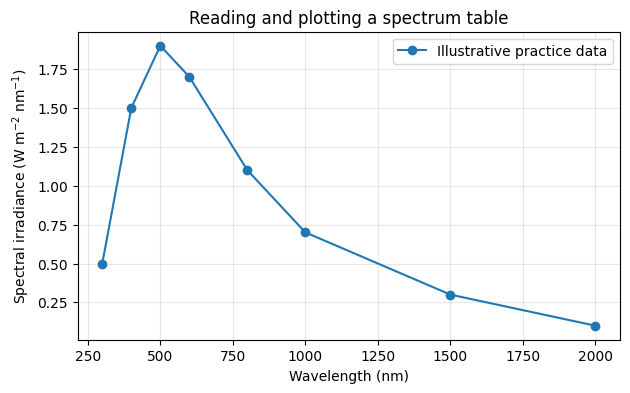

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(wavelength_nm, irradiance, "o-",
         label="Illustrative practice data")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Spectral irradiance (W m$^{-2}$ nm$^{-1}$)")
plt.title("Reading and plotting a spectrum table")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("figures/spectrum_example.png", dpi=300,
            bbox_inches="tight")
plt.show()
plt.close()

## Optional: evaluating a blackbody expression

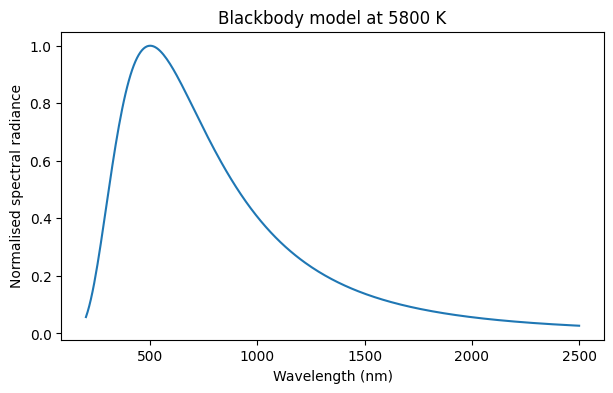

In [7]:
h = 6.62607015e-34
c = 299792458.0
k_B = 1.380649e-23
T_K = 5800.0
wavelength_nm = np.linspace(200, 2500, 300)
wavelength_m = wavelength_nm * 1e-9
exponent = h * c / (wavelength_m * k_B * T_K)
B = (2 * h * c**2 / wavelength_m**5) / np.expm1(exponent)

plt.figure(figsize=(7, 4))
plt.plot(wavelength_nm, B / B.max())
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalised spectral radiance")
plt.title("Blackbody model at 5800 K")
plt.show()
plt.close()